<a href="https://colab.research.google.com/github/sota-it/point-source-method/blob/main/HS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 11.3 MB/s eta 0:00:00


Loaded 15025 vertices from /content/13506_Diamond_Ring_v1_l3.obj


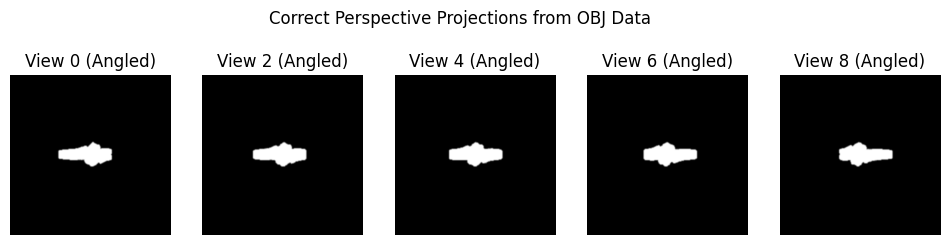

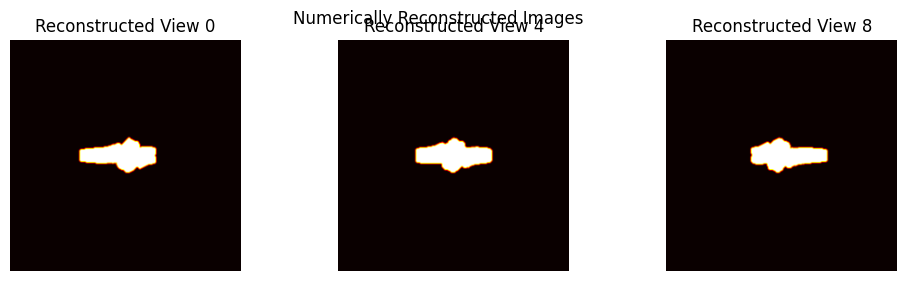

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import trimesh  # 3Dモデル読み込み用ライブラリ

# ==========================================
# 1. パラメータ設計 (物理定数・解像度)
# ==========================================
N_views = 9           # 視点数
res = 256             # 要素ホログラム(Hogol)の縦横ピクセル数
wavelength = 632.8e-9 # 再生レーザー波長 (赤色: 632.8 nm)
pixel_pitch = 8e-6    # ホログラムの画素ピッチ (8 um)
theta_y = np.deg2rad(1.2) # 参照光のY軸方向の入射角

# 参照光（平面波）の準備
k = 2 * np.pi / wavelength
y_coords = (np.arange(res) - res // 2) * pixel_pitch
x_coords = (np.arange(res) - res // 2) * pixel_pitch
X, Y = np.meshgrid(x_coords, y_coords)
Reference_Wave = np.exp(-1j * k * Y * np.sin(theta_y))

# ==========================================
# 2. .objファイルの読み込みと多視点透視投影画像の生成
# ==========================================
def load_obj_vertices(file_path):
    """ .obj ファイルから頂点データを読み込み、中心化とスケーリングを行う """
    # メッシュ（またはシーン）のロード
    mesh_or_scene = trimesh.load(file_path)

    # 読み込んだデータが Scene の場合は、含まれるすべてのメッシュの頂点を結合する
    if isinstance(mesh_or_scene, trimesh.Scene):
        if len(mesh_or_scene.geometry) == 0:
            raise ValueError("シーン内にメッシュ（Geometry）が見つかりません。")
        # すべてのサブメッシュの頂点を結合して1つの配列にする
        vertices_list = [np.array(geom.vertices) for geom in mesh_or_scene.geometry.values()]
        vertices = np.vstack(vertices_list)
    else:
        # 単一の Mesh オブジェクトだった場合
        vertices = np.array(mesh_or_scene.vertices)

    # 1) 物体の中心(重心)が原点 (0, 0, 0) になるように移動
    vertices -= np.mean(vertices, axis=0)

    # 2) サイズの正規化 (Blenderの巨大なモデルでも今回のカメラ座標系に適したサイズ[-40, 40]程度に収める)
    max_bound = np.max(np.abs(vertices))
    if max_bound > 0:
        vertices = (vertices / max_bound) * 40.0

    return vertices

def generate_yatagai_multiview_from_obj(file_path, n_views, resolution):
    # .obj から頂点データを取得
    points_3d = load_obj_vertices(file_path)
    print(f"Loaded {len(points_3d)} vertices from {file_path}")

    views = []

    # カメラのパラメータ (論文準拠の注視幾何学)
    R = 200.0   # 物体中心までの距離
    f = 300.0   # 焦点距離（拡大率）

    # 撮影角度の範囲 (-20度 から +20度 まで物体を回り込む)
    max_angle = np.deg2rad(20)
    angles = np.linspace(-max_angle, max_angle, n_views)

    for alpha in angles:
        img = np.zeros((resolution, resolution))

        for pt in points_3d:
            # 1) 物体中心を注視するカメラ座標系への回転・平行移動変換
            x_rot = pt[0] * np.cos(alpha) - pt[2] * np.sin(alpha)
            y_rot = pt[1]
            z_rot = pt[0] * np.sin(alpha) + pt[2] * np.cos(alpha) + R

            # 2) 正確な透視投影計算
            proj_x = int(resolution // 2 + (x_rot * f / z_rot))
            proj_y = int(resolution // 2 + (y_rot * f / z_rot))

            # ドットの描画
            if 0 <= proj_x < resolution and 0 <= proj_y < resolution:
                # 頂点数が多い場合はサイズを小さく(1〜2程度)するとシャープになります
                cv2.circle(img, (proj_x, proj_y), 1, 255, -1)

        # 頂点同士の密度に応じて適度にガウシアンぼかしを入れて物体光のつながりを滑らかにする
        img = cv2.GaussianBlur(img, (3, 3), 0) / 255.0
        views.append(img)
    return views

# --- .obj ファイルの指定 ---
# Colabにアップロードしたファイル名に変えてください（例: 'suzanne.obj'など）
obj_path = "/content/13506_Diamond_Ring_v1_l3.obj"

# 多視点画像の生成を実行
view_images = generate_yatagai_multiview_from_obj(obj_path, N_views, res)

# 視点画像のプレビュー表示
plt.figure(figsize=(12, 3))
for i in range(min(5, N_views)):
    idx = int(i * (N_views - 1) / 4)
    plt.subplot(1, 5, i+1)
    plt.imshow(view_images[idx], cmap='gray')
    plt.title(f"View {idx} (Angled)")
    plt.axis('off')
plt.suptitle("Correct Perspective Projections from OBJ Data")
plt.show()

# ==========================================
# 3. Yatagai論文方式によるHS合成
# ==========================================
hs_hologram = np.zeros((res, res * N_views), dtype=np.complex128)

for v_idx in range(N_views):
    img = view_images[v_idx]
    amplitude = np.sqrt(img)

    # ランダム位相の付与
    np.random.seed(v_idx)
    random_phase = np.random.rand(res, res) * 2 * np.pi
    u_object = amplitude * np.exp(1j * random_phase)

    # フーリエ変換
    U_object = np.fft.fftshift(np.fft.fft2(u_object))

    # 干渉縞計算
    fringe = U_object * np.conj(Reference_Wave)

    start_col = v_idx * res
    end_col = start_col + res
    hs_hologram[:, start_col:end_col] = fringe


# ==========================================
# 4. 数値的再生シミュレーション
# ==========================================
plt.figure(figsize=(12, 3))
for i, v_idx in enumerate([0, N_views//2, N_views-1]):
    start_col = v_idx * res
    hogol_part = hs_hologram[:, start_col:start_col+res]

    reconstructed_complex = np.fft.ifft2(np.fft.ifftshift(hogol_part * Reference_Wave))
    reconstructed_intensity = np.abs(reconstructed_complex)**2

    plt.subplot(1, 3, i+1)
    plt.imshow(reconstructed_intensity, cmap='hot')
    plt.title(f"Reconstructed View {v_idx}")
    plt.axis('off')
plt.suptitle("Numerically Reconstructed Images")
plt.show()